In [1]:
!pip install sinabs


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from pathlib import Path
import pandas as pd

saved_dir = Path(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD")

train_dfs = pd.read_pickle(saved_dir / "train_dfs.pkl")
test_dfs = pd.read_pickle(saved_dir / "test_dfs.pkl")

print("Reloaded train_dfs and test_dfs from saved_data/")
print("Train dfs:", len(train_dfs))
print("Test dfs:", len(test_dfs))
print("Train sizes:", [len(df) for df in train_dfs])
print("Test sizes:", [len(df) for df in test_dfs])

Reloaded train_dfs and test_dfs from saved_data/
Train dfs: 28
Test dfs: 28
Train sizes: [65010, 63341, 55726, 54014, 33464, 32452, 49539, 49505, 170718, 168763, 116716, 114204, 170841, 165956, 54322, 53784, 79703, 77806, 112684, 110737, 106590, 104997, 140756, 137805, 124842, 122961, 2393018, 850900]
Test sizes: [16252, 15835, 13931, 13503, 8365, 8113, 12384, 12376, 42679, 42190, 29178, 28550, 42710, 41488, 13580, 13446, 19925, 19451, 28171, 27684, 26647, 26249, 35189, 34451, 31210, 30740, 598254, 212724]


In [3]:
def data_to_uint8_array(data):
    if isinstance(data, bytes):
        arr = np.frombuffer(data, dtype=np.uint8)
    elif isinstance(data, str):
        s = data.strip()
        if s.startswith(("0x", "0X")):
            s = s[2:]
        if any(ch in s for ch in (" ", "-", ":", ",")):
            parts = [tok for tok in s.replace("-", " ").replace(":", " ").replace(",", " ").split() if tok]
            if all(len(tok) == 2 for tok in parts):
                arr = np.array([int(tok, 16) for tok in parts], dtype=np.uint8)
            else:
                arr = np.frombuffer(bytes.fromhex("".join(parts)), dtype=np.uint8)
        else:
            arr = np.frombuffer(bytes.fromhex(s), dtype=np.uint8)
    elif isinstance(data, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(data, dtype=np.uint8).flatten()
    elif isinstance(data, int):
        arr = np.frombuffer(data.to_bytes(8, byteorder="big", signed=False), dtype=np.uint8)
    else:
        raise TypeError(f"Unsupported Data type: {type(data)}")

    if arr.size < 8:
        arr = np.pad(arr, (0, 8 - arr.size), constant_values=0)
    elif arr.size > 8:
        arr = arr[:8]

    return arr

def sliding_windows_from_dfs(dfs, data_col="Data", window_size=32, step=2):
    windows = []
    next_values = []

    for df in dfs:
        values = df[data_col].tolist()
        byte_rows = np.stack([data_to_uint8_array(value) for value in values])

        for start in range(0, len(byte_rows) - window_size, step):
            end = start + window_size
            windows.append(byte_rows[start:end])
            next_values.append(byte_rows[end])

    return np.array(windows, dtype=np.uint8), np.array(next_values, dtype=np.uint8)

train_windows, train_next = sliding_windows_from_dfs(train_dfs, data_col="Data")
test_windows, test_next = sliding_windows_from_dfs(test_dfs, data_col="Data")

print("train_windows shape:", train_windows[0])
print("test_windows shape:", test_windows[0])

def sliding_windows_id_onehot_sums(dfs, id_onehot_col="ID_onehot", window_size=32, step=2):
    window_sums = []

    for df in dfs:
        if id_onehot_col not in df.columns:
            raise ValueError(f"Column {id_onehot_col!r} not found in DataFrame")

        id_onehot_arr = np.stack(df[id_onehot_col].tolist())

        if id_onehot_arr.ndim != 3 or id_onehot_arr.shape[1:] != (22, 8):
            raise ValueError(
                f"Expected {id_onehot_col} items to have shape (22, 8), "
                f"but got {id_onehot_arr.shape[1:]} from one DataFrame"
            )

        for start in range(0, len(id_onehot_arr) - window_size, step):
            window = id_onehot_arr[start:start + window_size]
            window_sums.append(window.sum(axis=0, dtype=np.uint16))

    return np.array(window_sums, dtype=np.uint16)


train_id_onehot_sums = sliding_windows_id_onehot_sums(train_dfs)
test_id_onehot_sums = sliding_windows_id_onehot_sums(test_dfs)

print("train_id_onehot_sums shape:", train_id_onehot_sums[0])
print("test_id_onehot_sums shape:", test_id_onehot_sums[0])

train_windows shape: [[  0   0   0   0   0  12   0  10]
 [137  47  96  11  10   1   0 128]
 [ 78 224   0   0  64   0   0   0]
 [  0 126  32  16   2   0  40 240]
 [  2 119   4  96  95   3 154   0]
 [  4  64   4 125  31 192  21  98]
 [144   0  65  31  64  63 109  96]
 [  1 244  15 199 203  31  82 154]
 [  0   6 120   0  12   2 215 208]
 [  0 242  32 252 144 124 141 217]
 [ 96   0   0   0   0   0   0   0]
 [  0   8   4  19 234  17 244 206]
 [  0  16 249 164 193  46  16 160]
 [ 32  82  86   2   8   9 118 214]
 [123  85  31 186 210  83 105  46]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  3  31   3  27   3  34   3  33]
 [ 32  19  64   0   0   1 136 128]
 [137  47  96  11  10   1   0 128]
 [  0   0   0   0   0   0  24  64]
 [  0   0   0   0   0   0   0   0]
 [ 10 119   4  96  94   3 154   0]
 [  0   6 112   0  12  66 215 208]
 [  0  16 250  36 193  46  16 160]
 [  0   0  18 128   0   0   0   0]
 [144   0  65  31  64  63  79  96]
 [  0  32  40  64   0   0 128  64]

In [4]:
"""# multiply non-zero entries by 8 then subtract 1; keep dtype uint16
train_id_onehot_sums = (
    (train_id_onehot_sums.astype(np.int32) * 8)
    - (train_id_onehot_sums != 0).astype(np.int32)
).astype(np.uint16)

test_id_onehot_sums = (
    (test_id_onehot_sums.astype(np.int32) * 8)
    - (test_id_onehot_sums != 0).astype(np.int32)
).astype(np.uint16)

print("train_id_onehot_sums dtype/shape:", train_id_onehot_sums.dtype, train_id_onehot_sums.shape)
print("test_id_onehot_sums dtype/shape:", test_id_onehot_sums.dtype, test_id_onehot_sums.shape)"""

'# multiply non-zero entries by 8 then subtract 1; keep dtype uint16\ntrain_id_onehot_sums = (\n    (train_id_onehot_sums.astype(np.int32) * 8)\n    - (train_id_onehot_sums != 0).astype(np.int32)\n).astype(np.uint16)\n\ntest_id_onehot_sums = (\n    (test_id_onehot_sums.astype(np.int32) * 8)\n    - (test_id_onehot_sums != 0).astype(np.int32)\n).astype(np.uint16)\n\nprint("train_id_onehot_sums dtype/shape:", train_id_onehot_sums.dtype, train_id_onehot_sums.shape)\nprint("test_id_onehot_sums dtype/shape:", test_id_onehot_sums.dtype, test_id_onehot_sums.shape)'

In [5]:
train_windows_combined = np.concatenate(
    [train_windows.astype(np.uint16), train_id_onehot_sums.astype(np.uint16)], axis=1
)
test_windows_combined = np.concatenate(
    [test_windows.astype(np.uint16), test_id_onehot_sums.astype(np.uint16)], axis=1
)

print("train_windows_combined shape:", train_windows_combined.shape)
print("test_windows_combined shape:", test_windows_combined.shape)

train_windows_combined shape: (2890134, 54, 8)
test_windows_combined shape: (722196, 54, 8)


In [6]:
def sliding_windows_attack_labels(dfs, attack_col="Attack", window_size=32, step=2):
    windows_labels = []
    
    for df in dfs:
        attacks = df[attack_col].tolist()
        
        for start in range(0, len(attacks) - window_size, step):
            window_slice = attacks[start:start + window_size]
            
            # If 'T' is in the window, label is 'T', otherwise 'R'
            label = 'T' if 'T' in window_slice else 'R'
            windows_labels.append(label)
    
    return np.array(windows_labels, dtype=object)

attack_labels_train = sliding_windows_attack_labels(train_dfs)
attack_labels_test = sliding_windows_attack_labels(test_dfs)

print("attack_labels_train shape:", attack_labels_train.shape)
print("attack_labels_test shape:", attack_labels_test.shape)
print("Sample labels (first 20):", attack_labels_train[:20])

attack_labels_train shape: (2890134,)
attack_labels_test shape: (722196,)
Sample labels (first 20): ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


In [7]:
windows = train_windows_combined
windows_test = test_windows_combined
windowed_labels = attack_labels_train
windowed_labels_test = attack_labels_test

windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels)), dtype=np.uint8)
attack_onehot[windowed_labels == 'T'] = 1

print(attack_onehot[:10])

windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test)), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'T'] = 1

print(attack_onehot_test[:10])

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [8]:
import torch
from torch.utils.data import Dataset


class CANDataset(Dataset):
    def __init__(
        self,
        windows,
        attack_onehot,
        train=True,
        is_spiking=False,
        time_window=100,
    ):
        # Convert to tensors
        self.windows = torch.as_tensor(windows, dtype=torch.float32)

        # Add channel dimension:
        # (N, H, W) -> (N, 1, H, W)
        if self.windows.ndim == 3:
            self.windows = self.windows.unsqueeze(1)

        self.labels = torch.as_tensor(attack_onehot, dtype=torch.long)

        self.is_spiking = is_spiking
        self.time_window = time_window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        img = self.windows[index]
        label = self.labels[index]

        if self.is_spiking:
            # Optional normalization if inputs are not already in [0,1]
            #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Generate spike train
            img = (
                torch.rand(self.time_window, *img.shape) < img
            ).float()

        return img, label

# Gamma preprocessing experiment

This section compares `gamma = 1.0`, `0.5`, `0.25`, and `0.125` using the same power-law preprocessing, ANN architecture, training settings, and SNN evaluation settings.

In [9]:
"""import numpy as np

# Find windows containing values > 255
bad_indices = np.where(np.any(windows > 255, axis=tuple(range(1, windows.ndim))))[0]

print(f"Found {len(bad_indices)} windows containing values > 1")

for i in bad_indices:
    print(f"\nWindow index: {i}")
    print(windows[i])
    print(f"Maximum value: {windows[i].max()}")"""

'import numpy as np\n\n# Find windows containing values > 255\nbad_indices = np.where(np.any(windows > 255, axis=tuple(range(1, windows.ndim))))[0]\n\nprint(f"Found {len(bad_indices)} windows containing values > 1")\n\nfor i in bad_indices:\n    print(f"\nWindow index: {i}")\n    print(windows[i])\n    print(f"Maximum value: {windows[i].max()}")'

Device: cpu
Gammas: [1.0, 0.5, 0.25, 0.125]
SNN timesteps: 100


RUNNING GAMMA = 1.0
Gamma 1.0: train range = 0.000000 to 0.996094
Gamma 1.0: test range = 0.000000 to 0.996094


Gamma 1.0 | Epoch 1/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Gamma 1.0 | Epoch 1/5 | Loss: 0.3312 | Accuracy: 85.40%


Gamma 1.0 | Epoch 2/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Gamma 1.0 | Epoch 2/5 | Loss: 0.1447 | Accuracy: 94.16%


...

Gamma 0.125 | Epoch 5/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Gamma 0.125 | Epoch 5/5 | Loss: 0.0614 | Accuracy: 97.69%

ANN results:
Accuracy:           92.57%
Weighted precision:  97.81%
Weighted recall:     92.57%
Weighted F1:         94.56%


SNN evaluation (100 timesteps):   0%|          | 0/72220 [00:00<?, ?it/s]


SNN results:
Accuracy:           62.00%
Weighted precision:  100.00%
Weighted recall:     62.00%
Weighted F1:         76.54%


GAMMA EXPERIMENT RESULTS


,gamma,ANN Accuracy (%),ANN Weighted Precision (%),ANN Weighted Recall (%),ANN Weighted F1 (%),SNN Accuracy (%),SNN Weighted Precision (%),SNN Weighted Recall (%),SNN Weighted F1 (%)
0,1.00,94.73,98.14,94.73,95.96,95.67,100.0,95.67,97.79
1,0.50,97.07,98.33,97.07,97.51,83.67,100.0,83.67,91.11
2,0.25,95.81,98.10,95.81,96.64,75.67,100.0,75.67,86.15
3,0.12,92.57,97.81,92.57,94.56,62.00,100.0,62.00,76.54


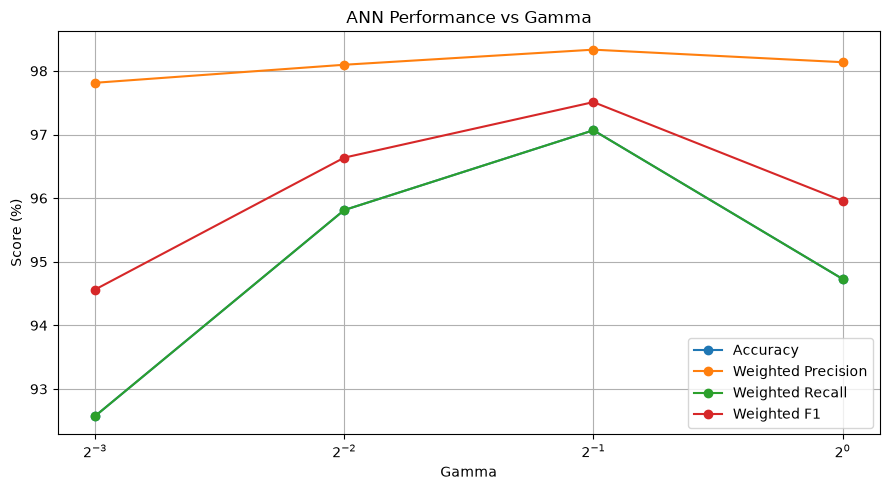

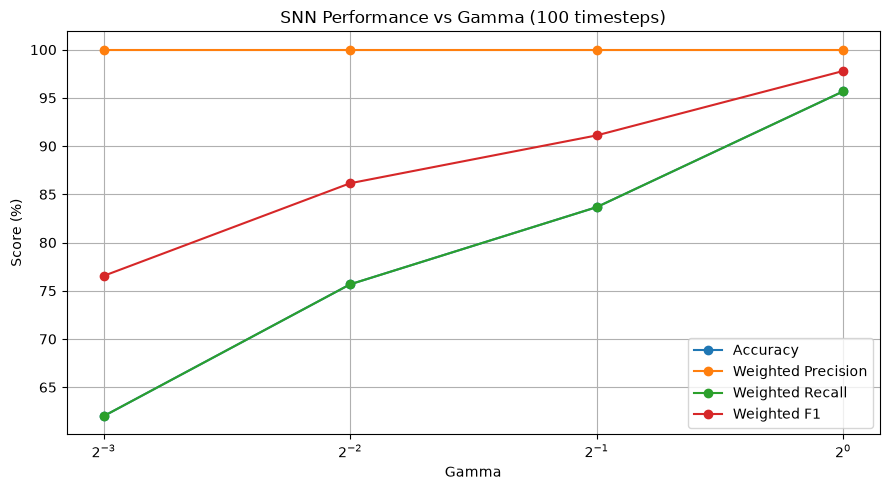


Best gamma based on SNN weighted F1:
Gamma = 1.0
SNN weighted F1 = 97.79%


In [10]:

# ============================================================
# GAMMA EXPERIMENT
# ============================================================
# This experiment compares the power-law preprocessing:
#
#     x_norm = (x / 256) ** gamma
#
# for:
#     gamma = 1.0
#     gamma = 0.5
#     gamma = 0.25
#     gamma = 0.125
#
# Each gamma gets:
#   1. Fresh preprocessed train/test data
#   2. A fresh copy of the same ANN architecture
#   3. Fresh ANN training
#   4. ANN test metrics
#   5. ANN -> Sinabs SNN conversion
#   6. SNN evaluation using rate coding
#   7. SNN accuracy, weighted precision, recall and F1
#
# The raw data is always taken from train_windows_combined and
# test_windows_combined so that one gamma does not overwrite the
# data used by the next gamma.
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from tqdm.auto import tqdm

from sinabs.from_torch import from_model
import sinabs.layers as sl


# ============================================================
# SETTINGS
# ============================================================

GAMMAS = [1.0, 0.5, 0.25, 0.125]

N_EPOCHS = 5
LEARNING_RATE = 1e-3

TRAIN_BATCH_SIZE = 2000
TEST_BATCH_SIZE = 10

# Number of SNN timesteps used for the gamma comparison.
# Change this if you want to compare at another timestep.
SNN_TIMESTEPS = 100

# Set to None to evaluate the complete SNN test set.
# A number such as 300 makes the experiment much faster.
MAX_SNN_SAMPLES = 300

SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Gammas:", GAMMAS)
print("SNN timesteps:", SNN_TIMESTEPS)


# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These improve reproducibility where possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# ANN ARCHITECTURE
# ============================================================

def create_ann():
    return nn.Sequential(
        # Input: (1, 54, 8)

        nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=(3, 3),
            stride=1,
            padding=0,
            bias=True
        ),
        nn.ReLU(),

        # Output: (32, 52, 6)

        nn.AvgPool2d(
            kernel_size=(2, 2),
            stride=(2, 2)
        ),

        # Output: (32, 26, 3)

        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=(3, 3),
            stride=1,
            padding=0,
            bias=True
        ),
        nn.ReLU(),

        # Output: (64, 24, 1)

        nn.Flatten(),

        # 64 × 24 × 1 = 1536
        nn.Linear(1536, 64),
        nn.ReLU(),

        nn.Linear(64, 2)
    )


# ============================================================
# PREPROCESSING
# ============================================================

def preprocess_gamma(gamma):
    """
    Apply the same power-law preprocessing used in the original
    notebook:

        (x / 256) ** gamma

    Raw data is copied from the original uint16 arrays so every
    gamma starts from exactly the same input values.
    """

    train = train_windows_combined.astype(np.float32, copy=True)
    test = test_windows_combined.astype(np.float32, copy=True)

    train = (train / 256.0) ** gamma
    test = (test / 256.0) ** gamma

    return train, test


# ============================================================
# ANN METRICS
# ============================================================

def evaluate_ann(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "weighted_precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
        "weighted_recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
    }


# ============================================================
# SNN EVALUATION
# ============================================================

def evaluate_snn(sinabs_model, windows_test_processed, timestep,
                 max_samples=None):
    """
    Rate-code the preprocessed input and evaluate the SNN.

    The SNN prediction is made by summing output spikes over time.
    """

    sinabs_model.eval()

    spike_dataset = CANDataset(
        windows_test_processed,
        attack_onehot_test,
        train=False,
        is_spiking=True,
        time_window=timestep
    )

    spike_loader = DataLoader(
        spike_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False
    )

    all_preds = []
    all_targets = []
    processed = 0

    with torch.no_grad():

        for data, target in tqdm(
            spike_loader,
            desc=f"SNN evaluation ({timestep} timesteps)",
            leave=False
        ):

            data = data.to(device)
            target = target.to(device)

            # Flatten time and batch dimensions for Sinabs.
            data = sl.FlattenTime()(data)

            output = sinabs_model(data)

            # Restore:
            # (batch*time, classes) -> (batch, time, classes)
            output = output.unflatten(
                0,
                (
                    target.shape[0],
                    output.shape[0] // target.shape[0]
                )
            )

            # Sum output spikes over time.
            pred = output.sum(1).argmax(dim=1)

            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())

            processed += target.shape[0]

            if max_samples is not None and processed >= max_samples:
                break

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "weighted_precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
        "weighted_recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ) * 100,
    }


# ============================================================
# RUN EXPERIMENT
# ============================================================

results = []

for gamma in GAMMAS:

    print("\n")
    print("=" * 70)
    print(f"RUNNING GAMMA = {gamma}")
    print("=" * 70)

    # --------------------------------------------------------
    # Reset seed so each gamma starts from the same
    # initialization/random state as far as practical.
    # --------------------------------------------------------
    set_seed(SEED)

    # --------------------------------------------------------
    # Preprocess from RAW data
    # --------------------------------------------------------
    windows_gamma, windows_test_gamma = preprocess_gamma(gamma)

    print(
        f"Gamma {gamma}: "
        f"train range = {windows_gamma.min():.6f} "
        f"to {windows_gamma.max():.6f}"
    )

    print(
        f"Gamma {gamma}: "
        f"test range = {windows_test_gamma.min():.6f} "
        f"to {windows_test_gamma.max():.6f}"
    )

    # --------------------------------------------------------
    # Create fresh DataLoaders
    # --------------------------------------------------------
    train_dataset = CANDataset(
        windows_gamma,
        attack_onehot,
        train=True,
        is_spiking=False
    )

    test_dataset = CANDataset(
        windows_test_gamma,
        attack_onehot_test,
        train=False,
        is_spiking=False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=2000,
        shuffle=False
    )

    # --------------------------------------------------------
    # Create FRESH ANN
    # --------------------------------------------------------
    ann = create_ann().to(device)

    optimizer = torch.optim.Adam(
        ann.parameters(),
        lr=LEARNING_RATE
    )

    # --------------------------------------------------------
    # Train ANN
    # --------------------------------------------------------
    ann.train()

    for epoch in range(N_EPOCHS):

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Gamma {gamma} | Epoch {epoch + 1}/{N_EPOCHS}"
        )

        for batch_idx, (data, target) in enumerate(progress_bar):

            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = ann(data)

            loss = F.cross_entropy(output, target)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += (pred == target).sum().item()
            total += target.size(0)

            accuracy = 100 * correct / total

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{accuracy:.2f}%"
            )

        print(
            f"Gamma {gamma} | "
            f"Epoch {epoch + 1}/{N_EPOCHS} | "
            f"Loss: {running_loss / len(train_loader):.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

    # --------------------------------------------------------
    # ANN evaluation
    # --------------------------------------------------------
    ann_metrics = evaluate_ann(ann, test_loader)

    print("\nANN results:")
    print(
        f"Accuracy:           {ann_metrics['accuracy']:.2f}%"
    )
    print(
        f"Weighted precision:  {ann_metrics['weighted_precision']:.2f}%"
    )
    print(
        f"Weighted recall:     {ann_metrics['weighted_recall']:.2f}%"
    )
    print(
        f"Weighted F1:         {ann_metrics['weighted_f1']:.2f}%"
    )

    # --------------------------------------------------------
    # ANN -> SNN conversion
    # --------------------------------------------------------
    input_shape = (1, 54, 8)

    sinabs_model = from_model(
        ann,
        input_shape=input_shape,
        add_spiking_output=True,
        synops=False,
        num_timesteps=SNN_TIMESTEPS
    )

    # --------------------------------------------------------
    # SNN evaluation
    # --------------------------------------------------------
    snn_metrics = evaluate_snn(
        sinabs_model,
        windows_test_gamma,
        timestep=SNN_TIMESTEPS,
        max_samples=MAX_SNN_SAMPLES
    )

    print("\nSNN results:")
    print(
        f"Accuracy:           {snn_metrics['accuracy']:.2f}%"
    )
    print(
        f"Weighted precision:  {snn_metrics['weighted_precision']:.2f}%"
    )
    print(
        f"Weighted recall:     {snn_metrics['weighted_recall']:.2f}%"
    )
    print(
        f"Weighted F1:         {snn_metrics['weighted_f1']:.2f}%"
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results.append({
        "gamma": gamma,

        "ANN Accuracy (%)":
            ann_metrics["accuracy"],

        "ANN Weighted Precision (%)":
            ann_metrics["weighted_precision"],

        "ANN Weighted Recall (%)":
            ann_metrics["weighted_recall"],

        "ANN Weighted F1 (%)":
            ann_metrics["weighted_f1"],

        "SNN Accuracy (%)":
            snn_metrics["accuracy"],

        "SNN Weighted Precision (%)":
            snn_metrics["weighted_precision"],

        "SNN Weighted Recall (%)":
            snn_metrics["weighted_recall"],

        "SNN Weighted F1 (%)":
            snn_metrics["weighted_f1"],
    })


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 90)
print("GAMMA EXPERIMENT RESULTS")
print("=" * 90)

display(results_df.round(2))


# ============================================================
# PLOT ANN RESULTS
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["gamma"],
    results_df["ANN Accuracy (%)"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["gamma"],
    results_df["ANN Weighted Precision (%)"],
    marker="o",
    label="Weighted Precision"
)

plt.plot(
    results_df["gamma"],
    results_df["ANN Weighted Recall (%)"],
    marker="o",
    label="Weighted Recall"
)

plt.plot(
    results_df["gamma"],
    results_df["ANN Weighted F1 (%)"],
    marker="o",
    label="Weighted F1"
)

plt.xlabel("Gamma")
plt.ylabel("Score (%)")
plt.title("ANN Performance vs Gamma")
plt.xscale("log", base=2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT SNN RESULTS
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["gamma"],
    results_df["SNN Accuracy (%)"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["gamma"],
    results_df["SNN Weighted Precision (%)"],
    marker="o",
    label="Weighted Precision"
)

plt.plot(
    results_df["gamma"],
    results_df["SNN Weighted Recall (%)"],
    marker="o",
    label="Weighted Recall"
)

plt.plot(
    results_df["gamma"],
    results_df["SNN Weighted F1 (%)"],
    marker="o",
    label="Weighted F1"
)

plt.xlabel("Gamma")
plt.ylabel("Score (%)")
plt.title(
    f"SNN Performance vs Gamma "
    f"({SNN_TIMESTEPS} timesteps)"
)
plt.xscale("log", base=2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# BEST GAMMA
# ============================================================

best_idx = results_df["SNN Weighted F1 (%)"].idxmax()
best_gamma = results_df.loc[best_idx, "gamma"]

print("\nBest gamma based on SNN weighted F1:")
print(f"Gamma = {best_gamma}")
print(
    f"SNN weighted F1 = "
    f"{results_df.loc[best_idx, 'SNN Weighted F1 (%)']:.2f}%"
)
